In [1]:
from modules.QCS import Gate, Functions, torch
from modules.Reinforcementlearning import SemiGradSarsa, Tile, torch, nn, random, plt, clear_output
from time import sleep
import ipywidgets

In [2]:
sarsa = SemiGradSarsa()

In [3]:
class ActionGates:

    def __init__(self, N_qbits, singlegates_config = "X Y Z H M",
                                doublegates_config = "CX CZ",
                                meassuregates_config = "MX MZ"):
        
        self.N_qbits = N_qbits
        targets = list(range(self.N_qbits))
        singlegate_targets = []
        for i in targets:
            singlegate_targets.append([i])
        
        doublegate_targets = []
        for i in targets:
            for j in targets:
                if abs(i-j)==1 and i != 0 and j != 0:
                    doublegate_targets.append([i,j])
        
        meassuregate_targets = []
        for i in targets:
            for j in targets:
                if abs(i-j)!=0 and i != 0:
                    meassuregate_targets.append([i,j])
        
        print(f"allowed single gates: {singlegates_config}")
        print(f"possible single targets: {singlegate_targets}")
        print(f"allowed double gates: {doublegates_config}")
        print(f"possible double control/target pairs: {doublegate_targets}")
        print(f"allowed measure gates: {meassuregates_config}")
        print(f"possible meassure meassure targets: {meassuregate_targets}")
        
        self.actions = []
        
        for gate in singlegates_config.split():
            for target in singlegate_targets:
                xy_bool = not (str(gate)[0] in ["X", "Z"] and target[0] in [1,2])
                m_bool = not (str(gate)[0] == "M" and target[0] == 0)
                if xy_bool and m_bool:
                    self.actions.append(Gate(gate, target))
                    
        for gate in doublegates_config.split():
            for target in doublegate_targets:
                self.actions.append(Gate(gate, target))
        for gate in meassuregates_config.split():
            for target in meassuregate_targets:
                self.actions.append(Gate(gate, target))
        print(f"{len(self.actions)} actions in total")

        random_state = Functions.random_state(self.N_qbits)

        try:
            for action in self.actions:
                check = action(random_state)
            print("every actions works!")
        except:
            print(f"{action} does not work!")

    def __getitem__(self, key):
        return self.actions[key]

    def __iter__(self):
        for action in self.actions:
            yield action

    def __str__(self):
        string = ""
        for i, action in enumerate(self.actions):
            if len(str(action)) < 10:
                string += f"{action} \t\t index: {i}\n"
            else:
                string += f"{action} \t index: {i}\n"
        return string

    def __len__(self):
        return len(self.actions)

In [4]:
'''''
Goal is to teleport state from qbit[2] -> qbit[0] 
'''''

class ActionEnviroment:
    def __init__(self, actions, max_steps, difficulty=4):
        sol_index = 6 - difficulty
        full_solution = [Gate("H", [1]), Gate("CX", [1,0]),
                 Gate("CX", [2, 1]), Gate("H", [2]),
                 Gate("MX", [1,0]), Gate("MZ", [2,0])]

        self.start = full_solution[:sol_index]
        self.solution = full_solution[sol_index:]
        
        self.random_state = Functions.random_state()
        self.actions = actions
        self.max_steps = max_steps

    def test_solution(self):
        state = self.setup()[0]
        for gate in self.solution:
            state = gate(state)[0]
        if self.terminal_check(state):
            print("Solution good!")
        else:
            print("Solution bad!")

    def test_net(self, qnet):
        try:
            S = env.setup()
            goal_reached = False
            for i in range(self.max_steps):
                q_values = qnet(S)
                if torch.abs(torch.std(q_values)) < 1e-9:
                    A = random.randint(0, len(self.actions)-1)
                else:
                    A = torch.argmax(q_values)
                S, R, goal_reached = self.step(S, A)
                if str(self.actions[A])[0] == "M" and len(self.actions[A].target)==1:
                    print(f"{self.actions[A]} \t meassurement: {S[1]}")
                else:
                    print(self.actions[A])
                sleep(0.5)
                if goal_reached:
                    print(f"\nGoal in {i+1} steps!")
                    break
            if not goal_reached:
                print(f"\nFailed in {i+1} steps!")                    
        except KeyboardInterrupt:
            clear_output()
        
    def terminal_check(self, state):
        p = torch.tensordot(torch.conj(state), state, dims=[[1,2],[1,2]])
        q = torch.conj(self.random_state).unsqueeze(-1) * self.random_state.unsqueeze(0)
        trace = torch.sum(p * q.T)
        return torch.abs(trace - 1) < 1e-6
    
    def setup(self):
        self.random_state = Functions.random_state()
        state = Functions.combine(Functions.classic_state([0,0], as_list=True) + [self.random_state])
        for gate in self.start:
            state = gate(state)[0]
        action_log = [-1 for _ in range(self.max_steps)]
        return (state, 0, action_log)

    def step(self, action_state, action):
        new_state, measurement = self.actions[action](action_state[0])
        
        new_action_log = action_state[2] * 1
        for i in range(self.max_steps):
            if new_action_log[i] == -1:
                new_action_log[i] = action
                break
                
        return (new_state, measurement, new_action_log), -1, self.terminal_check(new_state)

In [5]:
class ActionModel(nn.Module):
    def __init__(self, max_steps, N_actions):
        super(ActionModel, self).__init__()
        self.w = nn.Parameter(torch.zeros(max_steps, 2, N_actions+1, N_actions, requires_grad=True))
        self.max_steps = max_steps
        self.N_actions = N_actions
        
    def forward(self, action_state):
        last_gate_type = action_state[1]
        action_log = action_state[2]
        out = torch.zeros(self.N_actions)
        for i, index in enumerate(action_log):
            out += self.w[i, last_gate_type, index]
        return out

In [6]:
N_qbits = 3
actions = ActionGates(N_qbits, singlegates_config = "H X Z M",
                               doublegates_config = "CX",
                               meassuregates_config = "")
print("\n" + str(actions))

allowed single gates: H X Z M
possible single targets: [[0], [1], [2]]
allowed double gates: CX
possible double control/target pairs: [[1, 2], [2, 1]]
allowed measure gates: 
possible meassure meassure targets: [[1, 0], [1, 2], [2, 0], [2, 1]]
9 actions in total
every actions works!

H->[0] 		 index: 0
H->[1] 		 index: 1
H->[2] 		 index: 2
X->[0] 		 index: 3
Z->[0] 		 index: 4
M->[1] 		 index: 5
M->[2] 		 index: 6
C[1]->X[2] 	 index: 7
C[2]->X[1] 	 index: 8



In [7]:
max_steps = 10
env = ActionEnviroment(actions, max_steps, difficulty=4)
env.test_solution()

Solution good!


In [8]:
net = ActionModel(max_steps, N_actions=len(actions))

In [14]:
sarsa.set_log()

$S = (\varphi, m, log),\quad m\in{0,1}\quad log\in[-1,\ldots,N-1]^M$

Wobei $N$ Anzahl der Actions und $M$ Max. Anzahl der Schritte

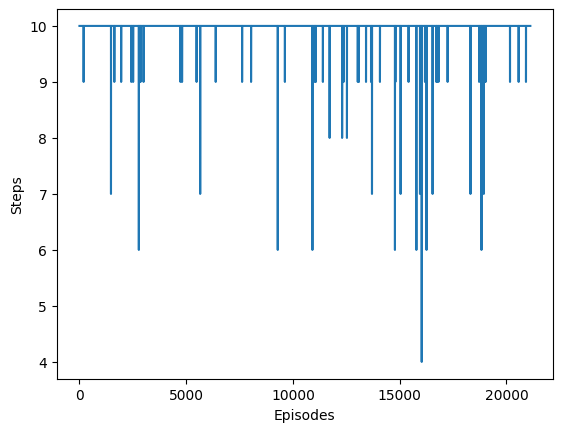

In [19]:
sarsa.run(env, net, max_episode=10000, max_steps=max_steps)

In [17]:
env.test_net(net)

H->[1]
M->[2] 	 meassurement: 0
H->[2]
Z->[0]
H->[1]
H->[1]
H->[2]
C[2]->X[1]
C[2]->X[1]
C[2]->X[1]

Failed in 10 steps!


In [16]:
S = env.setup()
for i in range(4):
    q = net(S)
    print(f"q-values in step {i+1}: {q}")
    a = torch.argmax(q)
    S = env.step(S, a)[0]


q-values in step 1: tensor([-10.0684,  -9.2646,  -9.4790,  -9.7405,  -9.6557,  -9.9108,  -9.4249,
         -9.7726,  -9.6339], grad_fn=<AddBackward0>)
q-values in step 2: tensor([-8.9688, -8.4445, -8.3592, -8.6570, -8.4135, -8.7151, -8.2721, -8.7517,
        -8.5149], grad_fn=<AddBackward0>)
q-values in step 3: tensor([-8.0340, -7.3308, -7.3070, -7.6647, -7.3448, -7.9465, -7.5753, -7.8068,
        -7.7197], grad_fn=<AddBackward0>)
q-values in step 4: tensor([-6.8894, -6.2133, -6.4313, -6.6437, -6.0746, -6.6849, -6.4333, -6.7115,
        -6.5203], grad_fn=<AddBackward0>)
